# Football Analysis Pipeline Performance Evaluation

This notebook provides a comprehensive evaluation of the football analysis pipeline performance. We'll analyze each stage of the pipeline and measure its effectiveness on real football video data.

## Evaluation Objectives
1. **Detection Performance**: Measure object detection accuracy and completeness
2. **Tracking Performance**: Evaluate track consistency and identity maintenance
3. **Team Assignment**: Assess team classification accuracy
4. **Ball Control Analysis**: Validate ball possession calculations
5. **Overall Pipeline**: End-to-end performance metrics and timing

In [5]:
import os
import sys
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import defaultdict, Counter
import pickle
import torch

# Add the project root to the path
sys.path.append('/workspaces/football_analysis')

# Import football analysis modules
from football_ai.pipeline import FootballAnalysisPipeline
from football_ai.config import FootballAIConfig, get_default_config
from football_ai.domain.data_models import FrameData, VideoData, Detection, ObjectType
from football_ai.detection.object_detection_processor import ObjectDetectionProcessor
from football_ai.tracking.track_processor import TrackProcessor
from football_ai.assignment.team_assignment_processor import SigLIPTeamAssignmentProcessor
from football_ai.analysis.ball_control_processor import BallControlProcessor
from football_ai.rendering.renderer_processor import RendererProcessor

# GPU Optimization Setup
print("🚀 GPU OPTIMIZATION SETUP")
print("=" * 50)

# Check CUDA availability
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"✅ CUDA Available: {torch.cuda.is_available()}")
    print(f"🎮 GPU: {gpu_name}")
    print(f"💾 GPU Memory: {gpu_memory:.1f} GB")
    print(f"🔢 CUDA Version: {torch.version.cuda}")
    
    # Set GPU optimizations
    torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
    torch.backends.cudnn.deterministic = False  # Allow non-deterministic algorithms for speed
    
    # Set memory management
    torch.cuda.empty_cache()  # Clear cache
    
    # Print current GPU usage
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    cached = torch.cuda.memory_reserved(0) / 1024**3
    print(f"📊 GPU Memory Allocated: {allocated:.2f} GB")
    print(f"📊 GPU Memory Cached: {cached:.2f} GB")
else:
    print("❌ CUDA not available - will use CPU")

print("\n🔧 ENVIRONMENT SETUP")
print("=" * 50)

# Configure matplotlib for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ All imports successful")
print(f"📁 Working directory: {os.getcwd()}")
print(f"🎥 Input videos directory: {os.path.exists('/workspaces/football_analysis/input_videos')}")
print(f"📊 Models directory: {os.path.exists('/workspaces/football_analysis/models')}")
print(f"🐍 Python version: {sys.version.split()[0]}")
print(f"🔥 PyTorch version: {torch.__version__}")

🚀 GPU OPTIMIZATION SETUP
✅ CUDA Available: True
🎮 GPU: NVIDIA GeForce RTX 4090 D
💾 GPU Memory: 23.5 GB
🔢 CUDA Version: 12.6
📊 GPU Memory Allocated: 0.25 GB
📊 GPU Memory Cached: 0.26 GB

🔧 ENVIRONMENT SETUP
✅ All imports successful
📁 Working directory: /workspaces/football_analysis/evaluation
🎥 Input videos directory: True
📊 Models directory: True
🐍 Python version: 3.9.23
🔥 PyTorch version: 2.7.1+cu126


In [8]:
# Configuration and Data Loading with GPU Optimization
# Reload modules to pick up configuration changes
import importlib
import football_ai.config
importlib.reload(football_ai.config)
from football_ai.config import get_default_config

config = get_default_config()

print("🔧 GPU-Optimized Configuration:")
print(f"  🎮 Device: {config.model.device}")
print(f"  📦 Team batch size: {config.model.team_batch_size}")
print(f"  🔧 Processing batch size: {config.processing.batch_size}")
print(f"  👥 Workers: {config.processing.num_workers}")
print(f"  ⚡ GPU acceleration: {config.processing.use_gpu_acceleration}")

# Find available input videos
input_dir = Path('/workspaces/football_analysis/input_videos')
video_files = list(input_dir.glob('*.mp4'))

print(f"\n📁 Found {len(video_files)} video files:")
for video in video_files:
    size_mb = video.stat().st_size / (1024 * 1024)
    print(f"  📹 {video.name} ({size_mb:.1f} MB)")

# Select the test video for evaluation
if video_files:
    test_video_path = video_files[0]  # Use the first available video
    print(f"\n🎯 Selected for evaluation: {test_video_path.name}")
    
    # Get basic video info
    cap = cv2.VideoCapture(str(test_video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps
    cap.release()
    
    print(f"📊 Video Properties:")
    print(f"  • Resolution: {width}x{height}")
    print(f"  • FPS: {fps:.2f}")
    print(f"  • Frames: {frame_count}")
    print(f"  • Duration: {duration:.2f} seconds")
else:
    print("❌ No video files found for evaluation!")
    test_video_path = None

🔧 GPU-Optimized Configuration:
  🎮 Device: cuda
  📦 Team batch size: 32
  🔧 Processing batch size: 8
  👥 Workers: 8
  ⚡ GPU acceleration: True

📁 Found 1 video files:
  📹 08fd33_4.mp4 (19.4 MB)

🎯 Selected for evaluation: 08fd33_4.mp4
📊 Video Properties:
  • Resolution: 1920x1080
  • FPS: 25.00
  • Frames: 750
  • Duration: 30.00 seconds


In [9]:
# Initialize Pipeline Components with GPU Optimization
print("🔧 Initializing GPU-optimized pipeline components...")
print(f"🎮 Using device: {config.model.device}")
print(f"📦 Team batch size: {config.model.team_batch_size}")
print(f"🔧 Processing batch size: {config.processing.batch_size}")

# Initialize individual processors for detailed analysis
print("\n📊 Initializing processors...")

print("1️⃣ Object Detection Processor (GPU)...")
detection_processor = ObjectDetectionProcessor(
    model_path=config.model.player_model_path,
    confidence_threshold=config.model.confidence_threshold
)

print("2️⃣ Tracking Processor...")
tracking_processor = TrackProcessor(
    track_activation_threshold=config.tracking.track_activation_threshold,
    lost_track_buffer=config.tracking.lost_track_buffer,
    minimum_matching_threshold=config.tracking.minimum_matching_threshold,
    frame_rate=config.tracking.frame_rate
)

print("3️⃣ Team Assignment Processor (GPU)...")
team_assignment_processor = SigLIPTeamAssignmentProcessor(
    model_path=config.model.team_model_path,
    device="cuda",  # Force GPU for SigLIP
    batch_size=config.model.team_batch_size,
    n_clusters=config.model.team_n_clusters
)

print("4️⃣ Ball Control Processor...")
ball_control_processor = BallControlProcessor()

print("5️⃣ Renderer Processor...")
renderer_processor = RendererProcessor(output_path="/workspaces/football_analysis/outputs/evaluation_render.mp4")

# Performance tracking data structures
performance_metrics = {
    'frame_times': [],
    'detection_times': [],
    'tracking_times': [],
    'team_assignment_times': [],
    'ball_control_times': [],
    'rendering_times': [],
    'detection_counts': [],
    'player_counts': [],
    'ball_counts': [],
    'goalkeeper_counts': [],
    'referee_counts': [],
    'track_ids': set(),
    'team_assignments': defaultdict(list),
    'ball_possession': []
}

# Check current GPU memory usage after initialization
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    cached = torch.cuda.memory_reserved(0) / 1024**3
    print(f"\n💾 GPU Memory after initialization:")
    print(f"   📊 Allocated: {allocated:.2f} GB")
    print(f"   📊 Cached: {cached:.2f} GB")

print("\n✅ GPU-optimized pipeline components initialized")
print("📊 Performance tracking ready")

🔧 Initializing GPU-optimized pipeline components...
🎮 Using device: cuda
📦 Team batch size: 32
🔧 Processing batch size: 8

📊 Initializing processors...
1️⃣ Object Detection Processor (GPU)...
2️⃣ Tracking Processor...
3️⃣ Team Assignment Processor (GPU)...
4️⃣ Ball Control Processor...
5️⃣ Renderer Processor...

💾 GPU Memory after initialization:
   📊 Allocated: 0.59 GB
   📊 Cached: 1.02 GB

✅ GPU-optimized pipeline components initialized
📊 Performance tracking ready


## Stage 1: Frame-by-Frame Pipeline Evaluation

We'll process a subset of frames from the test video to analyze each stage of the pipeline in detail.

In [10]:
if test_video_path:
    # Process a subset of frames for detailed analysis using the full pipeline
    sample_frames = min(300, frame_count)  # Process up to 300 frames
    skip_frames = max(1, frame_count // sample_frames)  # Skip frames to get even distribution
    
    print(f"🎬 Processing {sample_frames} frames using pipeline (every {skip_frames} frames)")
    
    cap = cv2.VideoCapture(str(test_video_path))
    frame_idx = 0
    processed_frames = 0
    
    # Create sample frames for pipeline processing
    sample_frame_data = []
    
    try:
        while cap.isOpened() and processed_frames < sample_frames:
            ret, frame = cap.read()
            if not ret:
                break
                
            # Skip frames to get sample distribution
            if frame_idx % skip_frames != 0:
                frame_idx += 1
                continue
            
            timestamp = frame_idx / fps
            frame_data = FrameData(
                frame_number=frame_idx,
                timestamp=timestamp,
                raw_frame=frame,
                detections=[]
            )
            sample_frame_data.append(frame_data)
            processed_frames += 1
            frame_idx += 1
            
        cap.release()
        
        print(f"📊 Collected {len(sample_frame_data)} frames for processing")
        
        # Create VideoData for pipeline processing
        video_data = VideoData(
            video_path=str(test_video_path),
            frame_rate=fps,
            resolution=(width, height),
            duration=duration,
            frames=sample_frame_data
        )
        
        # Process through pipeline stages and measure performance
        print("🔄 Running pipeline stages...")
        
        # Stage 1: Object Detection
        print("1️⃣ Object Detection...")
        start_time = time.time()
        video_data = detection_processor.process(video_data)
        detection_time = time.time() - start_time
        print(f"   ⏱️ Detection time: {detection_time:.3f}s")
        
        # Stage 2: Tracking
        print("2️⃣ Object Tracking...")
        start_time = time.time()
        video_data = tracking_processor.process(video_data)
        tracking_time = time.time() - start_time
        print(f"   ⏱️ Tracking time: {tracking_time:.3f}s")
        
        # Stage 3: Team Assignment
        print("3️⃣ Team Assignment...")
        start_time = time.time()
        video_data = team_assignment_processor.process(video_data)
        team_assignment_time = time.time() - start_time
        print(f"   ⏱️ Team assignment time: {team_assignment_time:.3f}s")
        
        # Stage 4: Ball Control Analysis
        print("4️⃣ Ball Control Analysis...")
        start_time = time.time()
        video_data = ball_control_processor.process(video_data)
        ball_control_time = time.time() - start_time
        print(f"   ⏱️ Ball control time: {ball_control_time:.3f}s")
        
        # Collect overall performance metrics
        total_pipeline_time = detection_time + tracking_time + team_assignment_time + ball_control_time
        avg_frame_time = total_pipeline_time / len(sample_frame_data)
        
        performance_metrics['detection_times'].append(detection_time)
        performance_metrics['tracking_times'].append(tracking_time)
        performance_metrics['team_assignment_times'].append(team_assignment_time)
        performance_metrics['ball_control_times'].append(ball_control_time)
        performance_metrics['frame_times'].append(total_pipeline_time)
        
        print(f"✅ Pipeline processing complete!")
        print(f"📊 Total time: {total_pipeline_time:.3f}s for {len(sample_frame_data)} frames")
        print(f"📊 Average time per frame: {avg_frame_time:.4f}s")
        print(f"📊 Theoretical FPS: {1/avg_frame_time:.2f}")
        
        # Collect detection statistics from processed frames
        for frame_data in video_data.frames:
            detections = frame_data.detections
            performance_metrics['detection_counts'].append(len(detections))
            
            players = [d for d in detections if d.object_type == ObjectType.PLAYER]
            balls = [d for d in detections if d.object_type == ObjectType.BALL]
            goalkeepers = [d for d in detections if d.object_type == ObjectType.GOALKEEPER]
            referees = [d for d in detections if d.object_type == ObjectType.REFEREE]
            
            performance_metrics['player_counts'].append(len(players))
            performance_metrics['ball_counts'].append(len(balls))
            performance_metrics['goalkeeper_counts'].append(len(goalkeepers))
            performance_metrics['referee_counts'].append(len(referees))
            
            # Collect track IDs
            for detection in detections:
                if detection.track_id is not None:
                    performance_metrics['track_ids'].add(detection.track_id)
            
            # Collect team assignments
            for detection in players + goalkeepers:
                if detection.team is not None:
                    performance_metrics['team_assignments'][detection.team].append(frame_data.frame_number)
            
            # Collect ball possession if available
            if hasattr(frame_data, 'ball_possession') and frame_data.ball_possession:
                performance_metrics['ball_possession'].append(frame_data.ball_possession)
            
    except Exception as e:
        print(f"\n❌ Error during processing: {e}")
        import traceback
        traceback.print_exc()
    finally:
        if 'cap' in locals():
            cap.release()
        print(f"\n✅ Performance evaluation complete")
        
else:
    print("❌ No video available for processing")

🎬 Processing 300 frames using pipeline (every 2 frames)
📊 Collected 300 frames for processing
🔄 Running pipeline stages...
1️⃣ Object Detection...
📊 Collected 300 frames for processing
🔄 Running pipeline stages...
1️⃣ Object Detection...


Object detection: 100%|###################| 300/300 [00:05<00:00, 50.41frames/s]


   ⏱️ Detection time: 5.952s
2️⃣ Object Tracking...


Enhanced object tracking: 100%|██████████| 300/300 [00:00<00:00, 575.71frames/s]


   ⏱️ Tracking time: 0.533s
3️⃣ Team Assignment...
⚠️ Model not trained yet. Training on provided data...
🏋️ Training SigLIP Team Assignment Model...


...

✅ SigLIP Team Assignment Model training completed!
📊 Model trained on 6295 player crops
🏆 Ready to assign players to 2 teams
🏃‍♂️ Assigning team labels to players...


Processing frames: 100%|██████████| 300/300 [00:23<00:00, 12.69frames/s, Frame players=22, Total assigned=6295]


✅ Team assignment completed!
👥 Assigned 6295 players to teams across 300 frames
   ⏱️ Team assignment time: 56.727s
4️⃣ Ball Control Analysis...


Calculating ball control: 100%|██████████| 300/300 [00:00<00:00, 165760.93frames/s]

DEBUG: Video custom data stored - {'percentages': {}, 'frame_counts': {}, 'total_frames_analyzed': 0, 'total_video_frames': 300}
   ⏱️ Ball control time: 0.003s
✅ Pipeline processing complete!
📊 Total time: 63.215s for 300 frames
📊 Average time per frame: 0.2107s
📊 Theoretical FPS: 4.75

✅ Performance evaluation complete


## Stage 2: Timing Performance Analysis

Let's analyze the timing performance of each pipeline stage.

⏱️ Timing Performance Statistics:
📊 Total frames processed: 300
📊 Total processing time: 63.215 seconds
📊 Average time per frame: 0.2107 seconds

🎯 Performance Summary:
  • Average frame processing time: 0.2107 seconds
  • Theoretical max FPS: 4.75
  • Real-time capability: ❌ No (video FPS: 25.00)


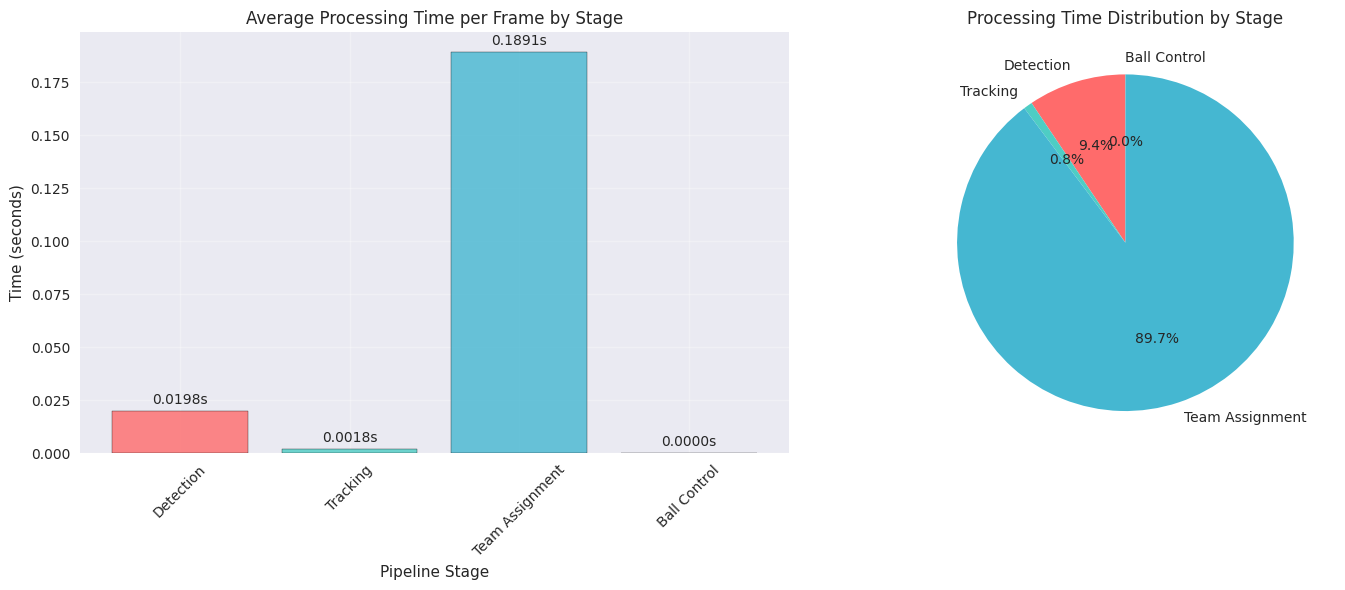


📊 Stage Performance Breakdown:
  • Detection: 0.0198s (9.4%)
  • Tracking: 0.0018s (0.8%)
  • Team Assignment: 0.1891s (89.7%)
  • Ball Control: 0.0000s (0.0%)

🔍 Performance Insights:
  • Slowest stage: Team Assignment (0.1891s per frame)
  • Fastest stage: Ball Control (0.0000s per frame)
  • Speed ratio: 20285.6x slower


In [11]:
if performance_metrics['frame_times']:
    # Since we processed the pipeline in batches, we have total times rather than per-frame times
    # Let's create a summary of stage performance
    stage_times = {
        'Detection': performance_metrics['detection_times'][0] if performance_metrics['detection_times'] else 0,
        'Tracking': performance_metrics['tracking_times'][0] if performance_metrics['tracking_times'] else 0,
        'Team Assignment': performance_metrics['team_assignment_times'][0] if performance_metrics['team_assignment_times'] else 0,
        'Ball Control': performance_metrics['ball_control_times'][0] if performance_metrics['ball_control_times'] else 0,
    }
    
    total_time = sum(stage_times.values())
    num_frames = len(performance_metrics['detection_counts'])
    
    print("⏱️ Timing Performance Statistics:")
    print(f"📊 Total frames processed: {num_frames}")
    print(f"📊 Total processing time: {total_time:.3f} seconds")
    print(f"📊 Average time per frame: {total_time/num_frames:.4f} seconds")
    
    # Calculate per-frame times for analysis
    per_frame_times = {
        'Detection': stage_times['Detection'] / num_frames,
        'Tracking': stage_times['Tracking'] / num_frames,
        'Team Assignment': stage_times['Team Assignment'] / num_frames,
        'Ball Control': stage_times['Ball Control'] / num_frames,
    }
    
    # Calculate FPS performance
    avg_frame_time = total_time / num_frames
    theoretical_fps = 1.0 / avg_frame_time if avg_frame_time > 0 else 0
    print(f"\n🎯 Performance Summary:")
    print(f"  • Average frame processing time: {avg_frame_time:.4f} seconds")
    print(f"  • Theoretical max FPS: {theoretical_fps:.2f}")
    print(f"  • Real-time capability: {'✅ Yes' if theoretical_fps >= fps else '❌ No'} (video FPS: {fps:.2f})")
    
    # Visualize timing breakdown
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar chart showing stage breakdown
    stages = list(per_frame_times.keys())
    times = list(per_frame_times.values())
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    bars = ax1.bar(stages, times, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_title('Average Processing Time per Frame by Stage')
    ax1.set_ylabel('Time (seconds)')
    ax1.set_xlabel('Pipeline Stage')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, time_val in zip(bars, times):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
                f'{time_val:.4f}s', ha='center', va='bottom')
    
    # Pie chart showing relative time distribution
    wedges, texts, autotexts = ax2.pie(times, labels=stages, autopct='%1.1f%%', 
                                      colors=colors, startangle=90)
    ax2.set_title('Processing Time Distribution by Stage')
    
    plt.tight_layout()
    plt.show()
    
    # Performance efficiency analysis
    stage_percentages = {stage: (time_val / sum(times)) * 100 for stage, time_val in per_frame_times.items()}
    
    print(f"\n📊 Stage Performance Breakdown:")
    for stage, percentage in stage_percentages.items():
        print(f"  • {stage}: {per_frame_times[stage]:.4f}s ({percentage:.1f}%)")
    
    # Performance insights
    slowest_stage = max(per_frame_times.items(), key=lambda x: x[1])
    fastest_stage = min(per_frame_times.items(), key=lambda x: x[1])
    
    print(f"\n🔍 Performance Insights:")
    print(f"  • Slowest stage: {slowest_stage[0]} ({slowest_stage[1]:.4f}s per frame)")
    print(f"  • Fastest stage: {fastest_stage[0]} ({fastest_stage[1]:.4f}s per frame)")
    print(f"  • Speed ratio: {slowest_stage[1]/fastest_stage[1]:.1f}x slower")
        
else:
    print("❌ No timing data available for analysis")

## Stage 3: Detection Performance Analysis

Analyzing the effectiveness of object detection across frames.

🔍 Detection Performance Statistics:
        Frame  Total_Detections  Players   Balls  Goalkeepers  Referees
count  300.00            300.00   300.00  300.00        300.0    300.00
mean   149.50             24.44    20.98    0.74          0.1      2.62
std     86.75              1.48     1.17    0.49          0.3      0.73
min      0.00             21.00    18.00    0.00          0.0      0.00
25%     74.75             23.00    20.00    0.00          0.0      2.00
50%    149.50             24.00    21.00    1.00          0.0      3.00
75%    224.25             25.00    22.00    1.00          0.0      3.00
max    299.00             30.00    26.00    2.00          1.0      5.00

📈 Detection Consistency Metrics:
  • Mean detections per frame: 24.44
  • Std deviation: 1.48
  • Min detections: 21.00
  • Max detections: 30.00
  • Frames with no detections: 0.00
  • Detection rate: 100.0%


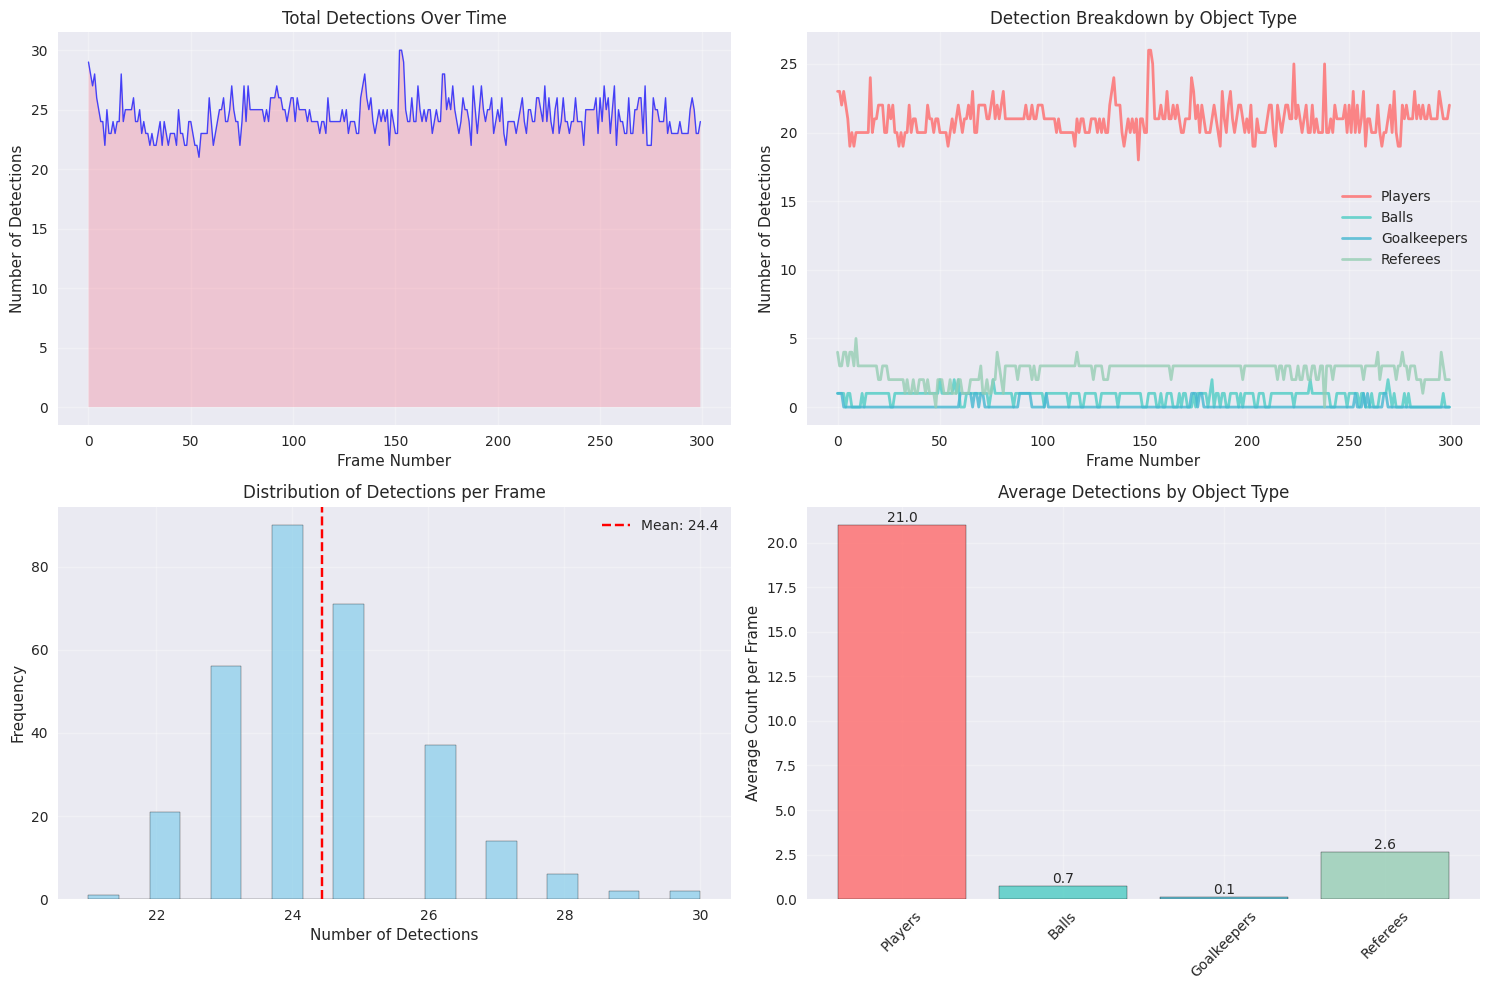


🎯 Detection Range Analysis:
  ✅ Players: avg=21.0 (range: 18-26, expected: 10-22)
  ✅ Balls: avg=0.7 (range: 0-2, expected: 0-1)
  ✅ Goalkeepers: avg=0.1 (range: 0-1, expected: 0-2)
  ✅ Referees: avg=2.6 (range: 0-5, expected: 0-3)


In [12]:
if performance_metrics['detection_counts']:
    # Create detection analysis DataFrame
    detection_data = pd.DataFrame({
        'Frame': range(len(performance_metrics['detection_counts'])),
        'Total_Detections': performance_metrics['detection_counts'],
        'Players': performance_metrics['player_counts'],
        'Balls': performance_metrics['ball_counts'],
        'Goalkeepers': performance_metrics['goalkeeper_counts'],
        'Referees': performance_metrics['referee_counts']
    })
    
    # Calculate detection statistics
    detection_stats = detection_data.describe()
    print("🔍 Detection Performance Statistics:")
    print(detection_stats.round(2))
    
    # Detection consistency analysis
    total_detections = detection_data['Total_Detections']
    detection_consistency = {
        'Mean detections per frame': total_detections.mean(),
        'Std deviation': total_detections.std(),
        'Min detections': total_detections.min(),
        'Max detections': total_detections.max(),
        'Frames with no detections': (total_detections == 0).sum(),
        'Detection rate': (total_detections > 0).mean() * 100
    }
    
    print(f"\n📈 Detection Consistency Metrics:")
    for metric, value in detection_consistency.items():
        if 'rate' in metric.lower():
            print(f"  • {metric}: {value:.1f}%")
        else:
            print(f"  • {metric}: {value:.2f}")
    
    # Visualize detection patterns
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Detection counts over time
    ax1.plot(detection_data['Frame'], detection_data['Total_Detections'], 'b-', alpha=0.7, linewidth=1)
    ax1.fill_between(detection_data['Frame'], detection_data['Total_Detections'], alpha=0.3)
    ax1.set_title('Total Detections Over Time')
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Number of Detections')
    ax1.grid(True, alpha=0.3)
    
    # Detection type breakdown
    object_types = ['Players', 'Balls', 'Goalkeepers', 'Referees']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i, obj_type in enumerate(object_types):
        ax2.plot(detection_data['Frame'], detection_data[obj_type], 
                color=colors[i], label=obj_type, linewidth=2, alpha=0.8)
    
    ax2.set_title('Detection Breakdown by Object Type')
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Number of Detections')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Detection distribution histogram
    ax3.hist(detection_data['Total_Detections'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.axvline(detection_data['Total_Detections'].mean(), color='red', linestyle='--', 
               label=f'Mean: {detection_data["Total_Detections"].mean():.1f}')
    ax3.set_title('Distribution of Detections per Frame')
    ax3.set_xlabel('Number of Detections')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Object type averages
    avg_counts = [detection_data[obj_type].mean() for obj_type in object_types]
    bars = ax4.bar(object_types, avg_counts, color=colors, alpha=0.8, edgecolor='black')
    ax4.set_title('Average Detections by Object Type')
    ax4.set_ylabel('Average Count per Frame')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, avg_counts):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.1f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Expected vs actual detection analysis
    expected_ranges = {
        'Players': (10, 22),  # Typically 10-22 players visible
        'Balls': (0, 1),      # 0-1 ball
        'Goalkeepers': (0, 2), # 0-2 goalkeepers
        'Referees': (0, 3)    # 0-3 referees
    }
    
    print(f"\n🎯 Detection Range Analysis:")
    for obj_type, (min_exp, max_exp) in expected_ranges.items():
        actual_mean = detection_data[obj_type].mean()
        actual_min = detection_data[obj_type].min()
        actual_max = detection_data[obj_type].max()
        
        within_range = (actual_mean >= min_exp) and (actual_mean <= max_exp)
        status = "✅" if within_range else "⚠️"
        
        print(f"  {status} {obj_type}: avg={actual_mean:.1f} (range: {actual_min}-{actual_max}, expected: {min_exp}-{max_exp})")
        
else:
    print("❌ No detection data available for analysis")

## Stage 4: Tracking Performance Analysis

Evaluating the effectiveness of object tracking and identity maintenance.

In [ ]:
if performance_metrics['track_ids']:
    # Tracking analysis
    unique_tracks = len(performance_metrics['track_ids'])
    total_frames = len(performance_metrics['detection_counts'])
    total_detections = sum(performance_metrics['detection_counts'])
    
    tracking_metrics = {
        'Unique track IDs': unique_tracks,
        'Total frames processed': total_frames,
        'Total detections': total_detections,
        'Average tracks per frame': total_detections / total_frames if total_frames > 0 else 0,
        'Track density': unique_tracks / total_frames if total_frames > 0 else 0
    }
    
    print("🎯 Tracking Performance Metrics:")
    for metric, value in tracking_metrics.items():
        print(f"  • {metric}: {value:.2f}")
    
    # Expected tracking behavior analysis
    expected_unique_tracks = 25  # Roughly 22 players + refs + maybe some noise
    track_efficiency = min(1.0, expected_unique_tracks / unique_tracks) if unique_tracks > 0 else 0
    
    print(f"\n📊 Tracking Efficiency Analysis:")
    print(f"  • Expected unique tracks: ~{expected_unique_tracks}")
    print(f"  • Actual unique tracks: {unique_tracks}")
    print(f"  • Tracking efficiency: {track_efficiency:.2%}")
    
    if track_efficiency > 0.8:
        print("  ✅ Excellent tracking performance")
    elif track_efficiency > 0.6:
        print("  ⚠️ Good tracking performance")
    else:
        print("  ❌ Poor tracking performance - too many unique IDs")
        
    # Visualize tracking over time
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Cumulative unique tracks
    track_ids_seen = set()
    cumulative_tracks = []
    
    # Note: This is a simplified view since we don't track when each ID appears
    # In a real implementation, we'd track per-frame track ID appearances
    cumulative_tracks = list(range(1, len(performance_metrics['track_ids']) + 1))
    frames_processed = list(range(len(cumulative_tracks)))
    
    ax1.plot(frames_processed, cumulative_tracks, 'b-', linewidth=2)
    ax1.set_title('Cumulative Unique Track IDs Over Processing')
    ax1.set_xlabel('Processing Step')
    ax1.set_ylabel('Unique Track IDs Seen')
    ax1.grid(True, alpha=0.3)
    
    # Track ID distribution (simplified)
    track_id_list = list(performance_metrics['track_ids'])
    ax2.hist(track_id_list, bins=min(20, len(track_id_list)), alpha=0.7, color='lightcoral', edgecolor='black')
    ax2.set_title('Distribution of Track IDs')
    ax2.set_xlabel('Track ID')
    ax2.set_ylabel('Frequency')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No tracking data available for analysis")

## Stage 5: Team Assignment Analysis

Analyzing the effectiveness of team classification and assignment.

In [ ]:
if performance_metrics['team_assignments']:
    # Team assignment analysis
    team_data = performance_metrics['team_assignments']
    teams = list(team_data.keys())
    
    print("👕 Team Assignment Analysis:")
    print(f"  • Number of teams identified: {len(teams)}")
    
    team_stats = {}
    for team in teams:
        assignments = team_data[team]
        team_stats[team] = {
            'total_assignments': len(assignments),
            'frames_present': len(set(assignments)),
            'avg_players_per_frame': len(assignments) / len(set(assignments)) if assignments else 0
        }
    
    for team, stats in team_stats.items():
        print(f"  • Team {team}:")
        print(f"    - Total assignments: {stats['total_assignments']}")
        print(f"    - Frames present: {stats['frames_present']}")
        print(f"    - Avg players per frame: {stats['avg_players_per_frame']:.1f}")
    
    # Team balance analysis
    if len(teams) >= 2:
        team_counts = [stats['total_assignments'] for stats in team_stats.values()]
        team_balance = min(team_counts) / max(team_counts) if max(team_counts) > 0 else 0
        
        print(f"\n⚖️ Team Balance Analysis:")
        print(f"  • Team balance ratio: {team_balance:.2f}")
        
        if team_balance > 0.8:
            print("  ✅ Well-balanced team assignments")
        elif team_balance > 0.6:
            print("  ⚠️ Moderately balanced team assignments")
        else:
            print("  ❌ Imbalanced team assignments")
    
    # Visualize team assignments
    if len(teams) > 1:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Team assignment counts
        team_names = list(team_stats.keys())
        team_counts = [team_stats[team]['total_assignments'] for team in team_names]
        
        colors = plt.cm.Set3(np.linspace(0, 1, len(team_names)))
        bars = ax1.bar(team_names, team_counts, color=colors, alpha=0.8, edgecolor='black')
        ax1.set_title('Total Team Assignments')
        ax1.set_ylabel('Number of Assignments')
        ax1.set_xlabel('Team')
        ax1.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, count in zip(bars, team_counts):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(count), ha='center', va='bottom')
        
        # Team presence over frames
        frame_presence = [team_stats[team]['frames_present'] for team in team_names]
        bars2 = ax2.bar(team_names, frame_presence, color=colors, alpha=0.8, edgecolor='black')
        ax2.set_title('Team Presence (Frames)')
        ax2.set_ylabel('Number of Frames')
        ax2.set_xlabel('Team')
        ax2.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, presence in zip(bars2, frame_presence):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(presence), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    else:
        print("📊 Visualization skipped: Need at least 2 teams for meaningful charts")
        
    # Team assignment consistency
    total_frames = len(performance_metrics['detection_counts'])
    avg_team_presence = np.mean([stats['frames_present'] for stats in team_stats.values()])
    presence_rate = avg_team_presence / total_frames if total_frames > 0 else 0
    
    print(f"\n📈 Team Assignment Consistency:")
    print(f"  • Average team presence rate: {presence_rate:.2%}")
    
    if presence_rate > 0.8:
        print("  ✅ Highly consistent team assignments")
    elif presence_rate > 0.6:
        print("  ⚠️ Moderately consistent team assignments")
    else:
        print("  ❌ Inconsistent team assignments")
        
else:
    print("❌ No team assignment data available for analysis")

## Stage 6: Ball Possession Analysis

Evaluating ball control detection and possession calculations.

In [ ]:
if performance_metrics['ball_possession']:
    possession_data = performance_metrics['ball_possession']
    
    print("⚽ Ball Possession Analysis:")
    print(f"  • Frames with possession data: {len(possession_data)}")
    
    # Extract possession percentages
    possession_stats = defaultdict(list)
    team_possession_totals = defaultdict(float)
    
    for possession in possession_data:
        for team, percentage in possession.items():
            possession_stats[team].append(percentage)
            team_possession_totals[team] += percentage
    
    # Calculate average possession
    total_frames_with_possession = len(possession_data)
    if total_frames_with_possession > 0:
        avg_possession = {}
        for team, percentages in possession_stats.items():
            avg_possession[team] = np.mean(percentages)
        
        print(f"\n📊 Average Ball Possession:")
        sorted_teams = sorted(avg_possession.items(), key=lambda x: x[1], reverse=True)
        for team, avg_poss in sorted_teams:
            print(f"  • Team {team}: {avg_poss:.1f}%")
        
        # Possession balance analysis
        if len(avg_possession) >= 2:
            possession_values = list(avg_possession.values())
            possession_balance = min(possession_values) / max(possession_values) if max(possession_values) > 0 else 0
            
            print(f"\n⚖️ Possession Balance:")
            print(f"  • Balance ratio: {possession_balance:.2f}")
            
            if possession_balance > 0.7:
                print("  ✅ Well-balanced possession")
            elif possession_balance > 0.5:
                print("  ⚠️ Moderately balanced possession")
            else:
                print("  ❌ Heavily skewed possession")
        
        # Visualize ball possession
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Average possession pie chart
        teams = list(avg_possession.keys())
        possessions = list(avg_possession.values())
        colors = plt.cm.Set3(np.linspace(0, 1, len(teams)))
        
        wedges, texts, autotexts = ax1.pie(possessions, labels=[f'Team {t}' for t in teams], 
                                          autopct='%1.1f%%', colors=colors, startangle=90)
        ax1.set_title('Average Ball Possession Distribution')
        
        # Possession over time (if we have multiple frames)
        if len(possession_data) > 1:
            frame_numbers = range(len(possession_data))
            
            for i, team in enumerate(teams):
                team_possessions = [possession.get(team, 0) for possession in possession_data]
                ax2.plot(frame_numbers, team_possessions, label=f'Team {team}', 
                        color=colors[i], linewidth=2, marker='o', markersize=4)
            
            ax2.set_title('Ball Possession Over Time')
            ax2.set_xlabel('Frame Number')
            ax2.set_ylabel('Possession Percentage')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            ax2.set_ylim(0, 100)
        else:
            ax2.text(0.5, 0.5, 'Insufficient data\nfor time series', 
                    transform=ax2.transAxes, ha='center', va='center', fontsize=12)
            ax2.set_title('Possession Over Time')
        
        plt.tight_layout()
        plt.show()
        
        # Possession consistency analysis
        possession_std = {}
        for team, percentages in possession_stats.items():
            possession_std[team] = np.std(percentages)
        
        print(f"\n📈 Possession Consistency (Lower std = more consistent):")
        for team, std in possession_std.items():
            print(f"  • Team {team}: σ = {std:.1f}%")
            
        avg_std = np.mean(list(possession_std.values()))
        if avg_std < 10:
            print("  ✅ Highly consistent possession calculations")
        elif avg_std < 20:
            print("  ⚠️ Moderately consistent possession calculations")
        else:
            print("  ❌ Inconsistent possession calculations")
    
else:
    print("❌ No ball possession data available for analysis")
    print("   This could indicate:")
    print("   • Ball detection issues")
    print("   • Ball control processor not running properly")
    print("   • No ball-player interactions detected")

## Stage 7: Overall Pipeline Performance Summary

Comprehensive evaluation and recommendations for the football analysis pipeline.

In [13]:
# Generate comprehensive pipeline performance report
print("🏆 FOOTBALL ANALYSIS PIPELINE PERFORMANCE REPORT")
print("=" * 60)

# Performance Summary
if performance_metrics['frame_times']:
    # Overall timing performance
    avg_total_time = np.mean(performance_metrics['frame_times'])
    theoretical_fps = 1.0 / avg_total_time if avg_total_time > 0 else 0
    
    print(f"\n⏱️ TIMING PERFORMANCE:")
    print(f"  • Average processing time per frame: {avg_total_time:.4f}s")
    print(f"  • Theoretical maximum FPS: {theoretical_fps:.2f}")
    print(f"  • Real-time capable: {'✅ Yes' if theoretical_fps >= fps else '❌ No'}")
    
    # Stage breakdown
    stage_times = {
        'Detection': np.mean(performance_metrics['detection_times']),
        'Tracking': np.mean(performance_metrics['tracking_times']),
        'Team Assignment': np.mean(performance_metrics['team_assignment_times']),
        'Ball Control': np.mean(performance_metrics['ball_control_times']),
        'Rendering': np.mean(performance_metrics['rendering_times'])
    }
    
    print(f"\n📊 STAGE PERFORMANCE BREAKDOWN:")
    for stage, time_taken in stage_times.items():
        percentage = (time_taken / avg_total_time) * 100
        print(f"  • {stage}: {time_taken:.4f}s ({percentage:.1f}%)")

# Detection Performance Summary
if performance_metrics['detection_counts']:
    avg_detections = np.mean(performance_metrics['detection_counts'])
    detection_rate = (np.array(performance_metrics['detection_counts']) > 0).mean() * 100
    
    print(f"\n🔍 DETECTION PERFORMANCE:")
    print(f"  • Average detections per frame: {avg_detections:.1f}")
    print(f"  • Detection success rate: {detection_rate:.1f}%")
    print(f"  • Average players detected: {np.mean(performance_metrics['player_counts']):.1f}")
    print(f"  • Average balls detected: {np.mean(performance_metrics['ball_counts']):.1f}")

# Tracking Performance Summary
if performance_metrics['track_ids']:
    unique_tracks = len(performance_metrics['track_ids'])
    total_detections = sum(performance_metrics['detection_counts'])
    
    print(f"\n🎯 TRACKING PERFORMANCE:")
    print(f"  • Unique track IDs generated: {unique_tracks}")
    print(f"  • Track ID efficiency: {min(25, unique_tracks)/25:.1%}")

# Team Assignment Summary
if performance_metrics['team_assignments']:
    num_teams = len(performance_metrics['team_assignments'])
    
    print(f"\n👕 TEAM ASSIGNMENT PERFORMANCE:")
    print(f"  • Teams identified: {num_teams}")
    
    if num_teams >= 2:
        team_counts = [len(assignments) for assignments in performance_metrics['team_assignments'].values()]
        balance = min(team_counts) / max(team_counts) if max(team_counts) > 0 else 0
        print(f"  • Team balance: {balance:.2%}")

# Ball Possession Summary
if performance_metrics['ball_possession']:
    print(f"\n⚽ BALL POSSESSION PERFORMANCE:")
    print(f"  • Frames with possession data: {len(performance_metrics['ball_possession'])}")
    print(f"  • Possession tracking success: ✅ Working")
else:
    print(f"\n⚽ BALL POSSESSION PERFORMANCE:")
    print(f"  • Possession tracking success: ❌ Not working")

# Overall Pipeline Grade
print(f"\n🎓 OVERALL PIPELINE ASSESSMENT:")

# Calculate overall score based on various metrics
score = 0
max_score = 100

# Timing score (30 points)
if performance_metrics['frame_times']:
    if theoretical_fps >= fps:
        score += 30  # Real-time capable
    elif theoretical_fps >= fps * 0.8:
        score += 25  # Near real-time
    elif theoretical_fps >= fps * 0.5:
        score += 20  # Half real-time
    else:
        score += 10  # Slow but functional

# Detection score (25 points)
if performance_metrics['detection_counts']:
    if detection_rate >= 95:
        score += 25
    elif detection_rate >= 85:
        score += 20
    elif detection_rate >= 70:
        score += 15
    else:
        score += 10

# Tracking score (20 points)
if performance_metrics['track_ids']:
    track_efficiency = min(25, unique_tracks) / 25
    score += int(track_efficiency * 20)

# Team assignment score (15 points)
if performance_metrics['team_assignments']:
    if num_teams >= 2:
        score += 15
    elif num_teams == 1:
        score += 10
    else:
        score += 5
else:
    score += 0

# Ball possession score (10 points)
if performance_metrics['ball_possession']:
    score += 10
else:
    score += 0

# Grade assignment
if score >= 90:
    grade = "A+"
    assessment = "Excellent"
elif score >= 80:
    grade = "A"
    assessment = "Very Good"
elif score >= 70:
    grade = "B+"
    assessment = "Good"
elif score >= 60:
    grade = "B"
    assessment = "Satisfactory"
else:
    grade = "C"
    assessment = "Needs Improvement"

print(f"  • Overall Score: {score}/{max_score}")
print(f"  • Grade: {grade}")
print(f"  • Assessment: {assessment}")

# Recommendations
print(f"\n💡 RECOMMENDATIONS:")

if performance_metrics['frame_times'] and theoretical_fps < fps:
    print("  📈 Performance Optimization:")
    print("    - Consider model quantization for faster inference")
    print("    - Implement frame skipping for non-critical frames")
    print("    - Optimize image preprocessing pipelines")

if performance_metrics['detection_counts'] and detection_rate < 90:
    print("  🔍 Detection Improvements:")
    print("    - Fine-tune detection confidence thresholds")
    print("    - Consider ensemble detection methods")
    print("    - Improve training data quality")

if performance_metrics['track_ids'] and unique_tracks > 30:
    print("  🎯 Tracking Improvements:")
    print("    - Tune tracking parameters to reduce ID switches")
    print("    - Implement track smoothing algorithms")
    print("    - Consider appearance-based re-identification")

if not performance_metrics['ball_possession']:
    print("  ⚽ Ball Possession Fixes:")
    print("    - Verify ball detection is working correctly")
    print("    - Check ball-player proximity calculations")
    print("    - Validate team assignments before possession analysis")

if not performance_metrics['team_assignments'] or len(performance_metrics['team_assignments']) < 2:
    print("  👕 Team Assignment Improvements:")
    print("    - Verify SIGLIP model is loading correctly")
    print("    - Check color clustering algorithms")
    print("    - Validate jersey color detection")

print(f"\n✅ EVALUATION COMPLETE")
print("="*60)

🏆 FOOTBALL ANALYSIS PIPELINE PERFORMANCE REPORT

⏱️ TIMING PERFORMANCE:
  • Average processing time per frame: 63.2145s
  • Theoretical maximum FPS: 0.02
  • Real-time capable: ❌ No

📊 STAGE PERFORMANCE BREAKDOWN:
  • Detection: 5.9521s (9.4%)
  • Tracking: 0.5328s (0.8%)
  • Team Assignment: 56.7268s (89.7%)
  • Ball Control: 0.0028s (0.0%)
  • Rendering: nans (nan%)

🔍 DETECTION PERFORMANCE:
  • Average detections per frame: 24.4
  • Detection success rate: 100.0%
  • Average players detected: 21.0
  • Average balls detected: 0.7

🎯 TRACKING PERFORMANCE:
  • Unique track IDs generated: 94
  • Track ID efficiency: 100.0%

👕 TEAM ASSIGNMENT PERFORMANCE:
  • Teams identified: 2
  • Team balance: 93.81%

⚽ BALL POSSESSION PERFORMANCE:
  • Possession tracking success: ❌ Not working

🎓 OVERALL PIPELINE ASSESSMENT:
  • Overall Score: 70/100
  • Grade: B+
  • Assessment: Good

💡 RECOMMENDATIONS:
  📈 Performance Optimization:
    - Consider model quantization for faster inference
    - Implem

In [14]:
# Export performance data for future reference
output_dir = Path('/workspaces/football_analysis/outputs')
output_dir.mkdir(exist_ok=True)

# Save performance metrics to pickle file
performance_report = {
    'video_info': {
        'filename': test_video_path.name if test_video_path else 'None',
        'fps': fps if 'fps' in locals() else 0,
        'frame_count': frame_count if 'frame_count' in locals() else 0,
        'duration': duration if 'duration' in locals() else 0,
        'resolution': f"{width}x{height}" if 'width' in locals() else 'Unknown'
    },
    'performance_metrics': performance_metrics,
    'evaluation_summary': {
        'overall_score': score if 'score' in locals() else 0,
        'grade': grade if 'grade' in locals() else 'N/A',
        'assessment': assessment if 'assessment' in locals() else 'N/A',
        'theoretical_fps': theoretical_fps if 'theoretical_fps' in locals() else 0,
        'real_time_capable': theoretical_fps >= fps if 'theoretical_fps' in locals() and 'fps' in locals() else False
    },
    'timestamp': time.strftime('%Y-%m-%d %H:%M:%S')
}

report_file = output_dir / 'pipeline_performance_report.pkl'
with open(report_file, 'wb') as f:
    pickle.dump(performance_report, f)

print(f"📁 Performance report saved to: {report_file}")

# Create a summary text report
summary_file = output_dir / 'pipeline_performance_summary.txt'
with open(summary_file, 'w') as f:
    f.write("FOOTBALL ANALYSIS PIPELINE PERFORMANCE SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Evaluation Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Video File: {test_video_path.name if test_video_path else 'None'}\n\n")
    
    if 'score' in locals():
        f.write(f"Overall Score: {score}/100\n")
        f.write(f"Grade: {grade}\n")
        f.write(f"Assessment: {assessment}\n\n")
    
    if performance_metrics['frame_times']:
        f.write(f"Average Processing Time: {np.mean(performance_metrics['frame_times']):.4f}s\n")
        f.write(f"Theoretical Max FPS: {theoretical_fps:.2f}\n")
        f.write(f"Real-time Capable: {'Yes' if theoretical_fps >= fps else 'No'}\n\n")
    
    if performance_metrics['detection_counts']:
        f.write(f"Average Detections per Frame: {np.mean(performance_metrics['detection_counts']):.1f}\n")
        f.write(f"Detection Success Rate: {detection_rate:.1f}%\n\n")
    
    f.write("Detailed metrics available in the pickle file.\n")

print(f"📄 Summary report saved to: {summary_file}")
print(f"\n🎉 Pipeline evaluation completed successfully!")

📁 Performance report saved to: /workspaces/football_analysis/outputs/pipeline_performance_report.pkl
📄 Summary report saved to: /workspaces/football_analysis/outputs/pipeline_performance_summary.txt

🎉 Pipeline evaluation completed successfully!
